### This file test the RePercENT model on synthetic data
_This is a testing notebook for all adjustments/changes to be done_

In [148]:
import sys
import os

sys.path.append(os.getcwd())
# append the root directory to the sys.path

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define imports here

In [149]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from src.utils.synthetic_dataset import GenerateData, MultimodalDataset
from src.utils.helpers import linear_probe, extract_latents_and_labels, plot_confusion_matrix, non_linear_probe
from src.models.repercent import RePercENT, DisenLoss
import math
from tqdm.notebook import tqdm
from torch.utils.data import random_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from training.train_repercent import make_model, split_dataset, ProbeEvaluator
from training.train_jointopt_2m import make_model_jointopt
import numpy as np
import yaml
from typing import Dict, Any, Callable, Optional, Sequence, Tuple, List, Union, Literal
import torch.nn as nn
from scipy.stats import vonmises_fisher, multivariate_normal
from itertools import combinations
import pandas as pd
import random

In [150]:
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Read config files

In [163]:
# Read the configuration files for data
M = 3  # Number of modalities
data_config_path = os.path.join(base_dir, "configs", "data", f"synthetic_data_{M}m.yaml")
with open(data_config_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Read the configuration files for training
training_config_path = os.path.join(base_dir, "configs", "training", f"train_synthetic_{M}m.yaml")
with open(training_config_path, 'r') as f:
    training_config = yaml.safe_load(f)

### Create a dataset for train / test

In [164]:
def create_dataset_synth(data_config):
    '''
    Create synthetic dataset based on the data configuration and save it to the specified path.
    Args:
        data_config: Configuration dictionary for the data.
    '''
    gen_data = GenerateData(N_data= data_config["create_data"]["N_data"], trans_type= data_config["create_data"]["trans_type"], latent_dim= data_config["create_data"]["latent_dim"], M = data_config["create_data"]["M"])
    gen_data.create_dataset(dist= data_config["create_data"]["dist"], ts= data_config["create_data"]["ts"], gammas= data_config["create_data"]["gammas"], normalize= data_config["create_data"]["normalize"], sigma= data_config["create_data"]["sigma"])
    dataset = MultimodalDataset(total_data= gen_data.dataset_dict['total_data'], labels_u= gen_data.dataset_dict['labels_u'], labels_s= gen_data.dataset_dict['labels_s'], t_u = gen_data.dataset_dict['t_u'], t_s = gen_data.dataset_dict['t_s'])
    gen_data.print_dataset_info()
    return dataset


dataset = create_dataset_synth(data_config)
train_dataset, test_dataset = split_dataset(dataset, test_size= training_config["training"]["test_size"])
train_dataloader = DataLoader(train_dataset, batch_size= training_config["training"]["batch_size"], shuffle= True)
test_dataloader = DataLoader(test_dataset, batch_size= training_config["training"]["batch_size"], shuffle= False)

Dataset Information:
Number of samples: 100000
Number of modalities: 3
Modality 1 data shape: (8, 32)
Modality 2 data shape: (8, 32)
Modality 3 data shape: (8, 32)
Labels for unique component u_12 shape: (100000,)
Labels for unique component u_13 shape: (100000,)
Labels for unique component u_21 shape: (100000,)
Labels for unique component u_23 shape: (100000,)
Labels for unique component u_31 shape: (100000,)
Labels for unique component u_32 shape: (100000,)
Labels for shared component s_12 shape: (100000,)
Labels for shared component s_13 shape: (100000,)
Labels for shared component s_23 shape: (100000,)
Latent factors for unique component u_12 shape: (100000, 16)
Latent factors for unique component u_13 shape: (100000, 16)
Latent factors for unique component u_21 shape: (100000, 16)
Latent factors for unique component u_23 shape: (100000, 16)
Latent factors for unique component u_31 shape: (100000, 16)
Latent factors for unique component u_32 shape: (100000, 16)
Latent factors for s

### Set seed for reproducibility

In [165]:
def set_seed(seed: int= 0):
    # Python & NumPy
    random.seed(seed)
    np.random.seed(seed)

    # PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Ensure deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # For CUDA >= 10.2
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
set_seed(0)

### Initialize model & load pretrained weights

In [181]:
model_type = "repercent"  # Options: "repercent", "jointopt"
# Read the configuration files for the model
model_config_path = os.path.join(base_dir, "configs", "model", f"{model_type}_{M}m.yaml")
with open(model_config_path, 'r') as f:
    print(f"Loading model configuration from: {model_config_path}")
    model_config = yaml.safe_load(f)
match model_type:
    case "repercent":
        # Define the disentangled encoders
        disenEncoders = [make_model(model_config, data_config, modality= m+1, M= data_config["create_data"]["M"]) for m in range(data_config["create_data"]["M"])]

        # Define the RePercENT model
        model= RePercENT(M= data_config["create_data"]["M"], disenEncoder= disenEncoders, disen_mapping= model_config["repercent"]["disen_mapping"]).to(device)
    case "jointopt":
        model = make_model_jointopt(model_config, data_config).to(device)
    case _:
        raise ValueError(f"Unknown model type: {model_type}")

disen_loss = DisenLoss(alpha= training_config["disen_loss"]["alpha"], lmd=training_config["disen_loss"]["lmd"], lmd_end_value= training_config["disen_loss"]["lmd_end_value"], M= data_config["create_data"]["M"], recon= training_config["disen_loss"]["recon"])
optimizer = torch.optim.Adam(model.parameters(), lr=training_config["optimizer"]["lr"], weight_decay= training_config["optimizer"]["weight_decay"])  

Loading model configuration from: /mnt/lts4-dislearn/scratch/home/rizou/lts4-FaP/configs/model/repercent_3m.yaml
input channels: 32, latent dim: 16, num latents: 4
input channels: 32, latent dim: 16, num latents: 4
input channels: 32, latent dim: 16, num latents: 4
RePercENT model initialized with latent dimension: 16, sequence dimension: 32


In [167]:
from torch.profiler import profile, ProfilerActivity

model.eval()

# Grab one batch and move to device
X_batch, _, _, _, _ = next(iter(train_dataloader))
X_batch = [x.to(device) for x in X_batch]

activities = [ProfilerActivity.CPU]
if torch.cuda.is_available():
    activities.append(ProfilerActivity.CUDA)

with profile(
    activities=activities,
    record_shapes=True,
    with_flops=True,
    profile_memory=False,
) as prof:
    with torch.no_grad():
        model(X_batch)
if torch.cuda.is_available():
    torch.cuda.synchronize()

# Aggregate FLOPs over all ops
total_flops = sum(evt.flops for evt in prof.key_averages() if evt.flops is not None)
print(f"Estimated FLOPs: {total_flops / 1e6:.2f} MFLOPs")
print(prof.key_averages().table(sort_by="flops", row_limit=15))

Estimated FLOPs: 7388.43 MFLOPs
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  Total MFLOPs  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::mm         2.99%       3.654ms         3.60%       4.394ms      73.235us       0.000us         0.00%       0.000us       0.000us            60      5190.451  
                                            aten::addmm         7.57%       9.248ms         8.30%      10.139ms     105

In [182]:
for _iter in range(training_config["training"]["n_epochs"]):
    epoch_loss = 0.0
    epoch_ortho_loss = 0.0
    epoch_unique_loss = 0.0
    epoch_shared_loss = 0.0
    epoch_recon_loss = 0.0
    
    model.train()
    print(f"Num of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
    print(f"----- Epoch: {_iter + 1} / {training_config['training']['n_epochs']} -----")

    # Training phase
    for batch_idx, (X, labels_u, labels_s, _, _) in enumerate(train_dataloader):
        temp_b = X[0].shape[0]
        X = [X[m].to(device) for m in range(len(X))]

        # Augment data
        X_aug = [GenerateData.augment_data(X[m], aug_type="random") for m in range(len(X))]
        
        out = model(X)
        out_aug = model(X_aug)

        loss, loss_logs = disen_loss(out, out_aug)
        
        optimizer.zero_grad(set_to_none= True)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() / temp_b 
        epoch_ortho_loss += loss_logs['ortho'] / temp_b
        epoch_unique_loss += loss_logs['unique'] / temp_b
        epoch_shared_loss += loss_logs['shared'] / temp_b
        epoch_recon_loss += loss_logs.get('recon', 0.0) / temp_b
        
    print(f"Train Loss (x 100): {100 * epoch_loss / (len(train_dataloader)):.4f} | Ortho Loss (x 100): {100 * epoch_ortho_loss / (len(train_dataloader)):.4f} | \
Unique Loss (x 100): {100 * epoch_unique_loss / (len(train_dataloader)):.4f} | Shared Loss (x 100): {100 * epoch_shared_loss / (len(train_dataloader)):.4f} | \
Recon Loss (x 100): {100 * loss_logs.get('recon', 0.0) / (len(train_dataloader)):.4f}")

    model.eval()
    with torch.no_grad():
        val_epoch_loss = 0.0
        val_epoch_ortho_loss = 0.0
        val_epoch_unique_loss = 0.0
        val_epoch_shared_loss = 0.0
        val_epoch_recon_loss = 0.0
        for batch_idx, (X, labels_u, labels_s, _, _) in enumerate(test_dataloader):
            temp_b = X[0].shape[0]
            X = [X[m].to(device) for m in range(len(X))]
            # Augment data
            X_aug = [GenerateData.augment_data(X[m], aug_type="random") for m in range(len(X))]

            out = model(X)
            out_aug = model(X_aug)
            val_loss, val_loss_logs = disen_loss(out, out_aug)

            val_epoch_loss += val_loss.item() / temp_b
            val_epoch_ortho_loss += val_loss_logs['ortho'] / temp_b
            val_epoch_unique_loss += val_loss_logs['unique'] / temp_b
            val_epoch_shared_loss += val_loss_logs['shared'] / temp_b
            val_epoch_recon_loss += val_loss_logs.get('recon', 0.0) / temp_b
    print(f"----- Validation after Epoch: {_iter + 1} / {training_config['training']['n_epochs']} -----")
    print(f"Val Loss (x 100): {100 * val_epoch_loss / (len(test_dataloader)):.4f} | Ortho Loss (x 100): {100 * val_epoch_ortho_loss / (len(test_dataloader)):.4f} | \
Unique Loss (x 100): {100 * val_epoch_unique_loss / (len(test_dataloader)):.4f} | Shared Loss (x 100): {100 * val_epoch_shared_loss / (len(test_dataloader)):.4f} | \
Recon Loss (x 100): {100 * val_epoch_recon_loss / (len(test_dataloader)):.4f}")   
    # components = list(train_data_dict['Labels_U'].keys()) + list(train_data_dict['Labels_S'].keys())
    
    # linear_probe_acc = calculate_linear_probe(train_data_dict, val_data_dict)
    # plot_confusion_matrix(linear_probe_acc, labels= components, components= components)
    # break

Num of parameters: 655218
----- Epoch: 1 / 50 -----
Train Loss (x 100): 1.1297 | Ortho Loss (x 100): 67.2440 | Unique Loss (x 100): 0.1600 | Shared Loss (x 100): 0.6368 | Recon Loss (x 100): 0.0000
----- Validation after Epoch: 1 / 50 -----
Val Loss (x 100): 0.8023 | Ortho Loss (x 100): 46.4007 | Unique Loss (x 100): 0.0467 | Shared Loss (x 100): 0.5202 | Recon Loss (x 100): 0.0000
Num of parameters: 655218
----- Epoch: 2 / 50 -----
Train Loss (x 100): 0.6396 | Ortho Loss (x 100): 46.2683 | Unique Loss (x 100): 0.0335 | Shared Loss (x 100): 0.4116 | Recon Loss (x 100): 0.0000
----- Validation after Epoch: 2 / 50 -----
Val Loss (x 100): 0.4931 | Ortho Loss (x 100): 43.8965 | Unique Loss (x 100): 0.0261 | Shared Loss (x 100): 0.3108 | Recon Loss (x 100): 0.0000
Num of parameters: 655218
----- Epoch: 3 / 50 -----
Train Loss (x 100): 0.4034 | Ortho Loss (x 100): 38.6515 | Unique Loss (x 100): 0.0206 | Shared Loss (x 100): 0.2529 | Recon Loss (x 100): 0.0000
----- Validation after Epoch: 3 

In [183]:
from src.utils.helpers import regression_probe    
train_data_dict = extract_latents_and_labels(model, train_dataloader, device)
val_data_dict = extract_latents_and_labels(model, test_dataloader, device)

evaluator = ProbeEvaluator(linear_probe= linear_probe, regression_probe= regression_probe)
evaluator.set_data(train_data_dict= train_data_dict, val_data_dict= val_data_dict, M= M)
linear_results = evaluator.calculate_linear_probe()
reg_results = evaluator.calculate_reg_probe()

metrics_summary = evaluator.mean_metrics(linear_results, reg_results, M= M)

In [184]:
import pandas as pd
pd.set_option("display.max_rows", None)

mean_linear_df = pd.DataFrame(metrics_summary, index= ["Value"])
# expand the dataframe for better visualization
display(mean_linear_df.T)

,Value
linear_probe/u2u_acc_mean,69.219162
linear_probe/u2u_acc_std,6.962324
linear_probe/u2s_acc_mean,56.410000
linear_probe/u2s_acc_std,5.344241
linear_probe/s2u_acc_mean,55.210831
linear_probe/s2u_acc_std,0.278944
linear_probe/s2s_acc_mean,78.738335
linear_probe/s2s_acc_std,5.869646
linear_probe/u2u_mcc_mean,0.384388
linear_probe/u2u_mcc_std,0.139246


### Train Jointopt

In [179]:
model_type = "jointopt"  # Options: "repercent", "jointopt"
# Read the configuration files for the model
model_config_path = os.path.join(base_dir, "configs", "model", f"{model_type}_{M}m.yaml")
with open(model_config_path, 'r') as f:
    model_config = yaml.safe_load(f)
match model_type:
    case "repercent":
        # Define the disentangled encoders
        disenEncoders = [make_model(model_config, data_config, modality= m+1, M= data_config["create_data"]["M"]) for m in range(data_config["create_data"]["M"])]

        # Define the RePercENT model
        model= RePercENT(M= data_config["create_data"]["M"], disenEncoder= disenEncoders, disen_mapping= model_config["repercent"]["disen_mapping"]).to(device)
    case "jointopt":
        model_joint = make_model_jointopt(model_config, data_config).to(device)
    case _:
        raise ValueError(f"Unknown model type: {model_type}")

disen_loss = DisenLoss(alpha= training_config["disen_loss"]["alpha"], lmd=training_config["disen_loss"]["lmd"], lmd_end_value= training_config["disen_loss"]["lmd_end_value"], M= data_config["create_data"]["M"], recon= training_config["disen_loss"]["recon"])
optimizer = torch.optim.Adam(model_joint.parameters(), lr=training_config["optimizer"]["lr"], weight_decay= training_config["optimizer"]["weight_decay"])  

In [180]:
for _iter in range(training_config["training"]["n_epochs"]):
    epoch_loss = 0.0
    epoch_ortho_loss = 0.0
    epoch_unique_loss = 0.0
    epoch_shared_loss = 0.0
    
    model_joint.train()
    print(f"Num of parameters: {sum(p.numel() for p in model_joint.parameters() if p.requires_grad)}")
    print(f"----- Epoch: {_iter + 1} / {training_config['training']['n_epochs']} -----")

    # Training phase
    for batch_idx, (X, labels_u, labels_s, _, _) in enumerate(train_dataloader):
        temp_b = X[0].shape[0]
        X = [X[m].to(device) for m in range(len(X))]

        # Augment data
        X_aug = [GenerateData.augment_data(X[m], aug_type="random") for m in range(len(X))]
        
        out = model_joint(X)
        out_aug = model_joint(X_aug)
        
        loss, loss_logs = disen_loss(out, out_aug)
        
        optimizer.zero_grad(set_to_none= True)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() / temp_b 
        epoch_ortho_loss += loss_logs['ortho'] / temp_b
        epoch_unique_loss += loss_logs['unique'] / temp_b
        epoch_shared_loss += loss_logs['shared'] / temp_b
    print(f"Train Loss (x 100): {100 * epoch_loss / (len(train_dataloader)):.4f} | Ortho Loss (x 100): {100 * epoch_ortho_loss / (len(train_dataloader)):.4f} | \
Unique Loss (x 100): {100 * epoch_unique_loss / (len(train_dataloader)):.4f} | Shared Loss (x 100): {100 * epoch_shared_loss / (len(train_dataloader)):.4f}")

    model_joint.eval()
    with torch.no_grad():
        val_epoch_loss = 0.0
        val_epoch_ortho_loss = 0.0
        val_epoch_unique_loss = 0.0
        val_epoch_shared_loss = 0.0
        val_epoch_recon_loss = 0.0
        for batch_idx, (X, labels_u, labels_s, _, _) in enumerate(test_dataloader):
            temp_b = X[0].shape[0]
            X = [X[m].to(device) for m in range(len(X))]
            # Augment data
            X_aug = [GenerateData.augment_data(X[m], aug_type="random") for m in range(len(X))]

            out = model_joint(X)
            out_aug = model_joint(X_aug)
            val_loss, val_loss_logs = disen_loss(out, out_aug)

            val_epoch_loss += val_loss.item() / temp_b
            val_epoch_ortho_loss += val_loss_logs['ortho'] / temp_b
            val_epoch_unique_loss += val_loss_logs['unique'] / temp_b
            val_epoch_shared_loss += val_loss_logs['shared'] / temp_b
            val_epoch_recon_loss += val_loss_logs.get('recon', 0.0) / temp_b
    print(f"----- Validation after Epoch: {_iter + 1} / {training_config['training']['n_epochs']} -----")
    print(f"Val Loss (x 100): {100 * val_epoch_loss / (len(test_dataloader)):.4f} | Ortho Loss (x 100): {100 * val_epoch_ortho_loss / (len(test_dataloader)):.4f} | \
Unique Loss (x 100): {100 * val_epoch_unique_loss / (len(test_dataloader)):.4f} | Shared Loss (x 100): {100 * val_epoch_shared_loss / (len(test_dataloader)):.4f} | \
Recon Loss (x 100): {100 * val_epoch_recon_loss / (len(test_dataloader)):.4f}")   
    # components = list(train_data_dict['Labels_U'].keys()) + list(train_data_dict['Labels_S'].keys())
    # linear_probe_acc = calculate_linear_probe(train_data_dict, val_data_dict)
    # plot_confusion_matrix(linear_probe_acc, labels= components, components= components)
    # break

Num of parameters: 1136832
----- Epoch: 1 / 50 -----


KeyboardInterrupt: 

In [161]:
from src.utils.helpers import regression_probe
train_data_dict = extract_latents_and_labels(model_joint, train_dataloader, device)
val_data_dict = extract_latents_and_labels(model_joint, test_dataloader, device)

evaluator = ProbeEvaluator(linear_probe= linear_probe, regression_probe= regression_probe)
evaluator.set_data(train_data_dict= train_data_dict, val_data_dict= val_data_dict, M= M)
linear_results = evaluator.calculate_linear_probe()
reg_results = evaluator.calculate_reg_probe()

metrics_summary = evaluator.mean_metrics(linear_results, reg_results, M= M)

In [162]:
pd.set_option("display.max_rows", None)

mean_linear_df = pd.DataFrame(metrics_summary, index= ["Value"])
# expand the dataframe for better visualization
display(mean_linear_df.T)

,Value
linear_probe/u2u_acc_mean,7.149001e+01
linear_probe/u2u_acc_std,2.450000e-01
linear_probe/u2s_acc_mean,5.804000e+01
linear_probe/u2s_acc_std,9.850000e-01
linear_probe/s2u_acc_mean,5.665000e+01
linear_probe/s2u_acc_std,1.525879e-06
linear_probe/s2s_acc_mean,7.782500e+01
linear_probe/s2s_acc_std,3.051758e-06
linear_probe/u2u_mcc_mean,4.298483e-01
linear_probe/u2u_mcc_std,4.872863e-03


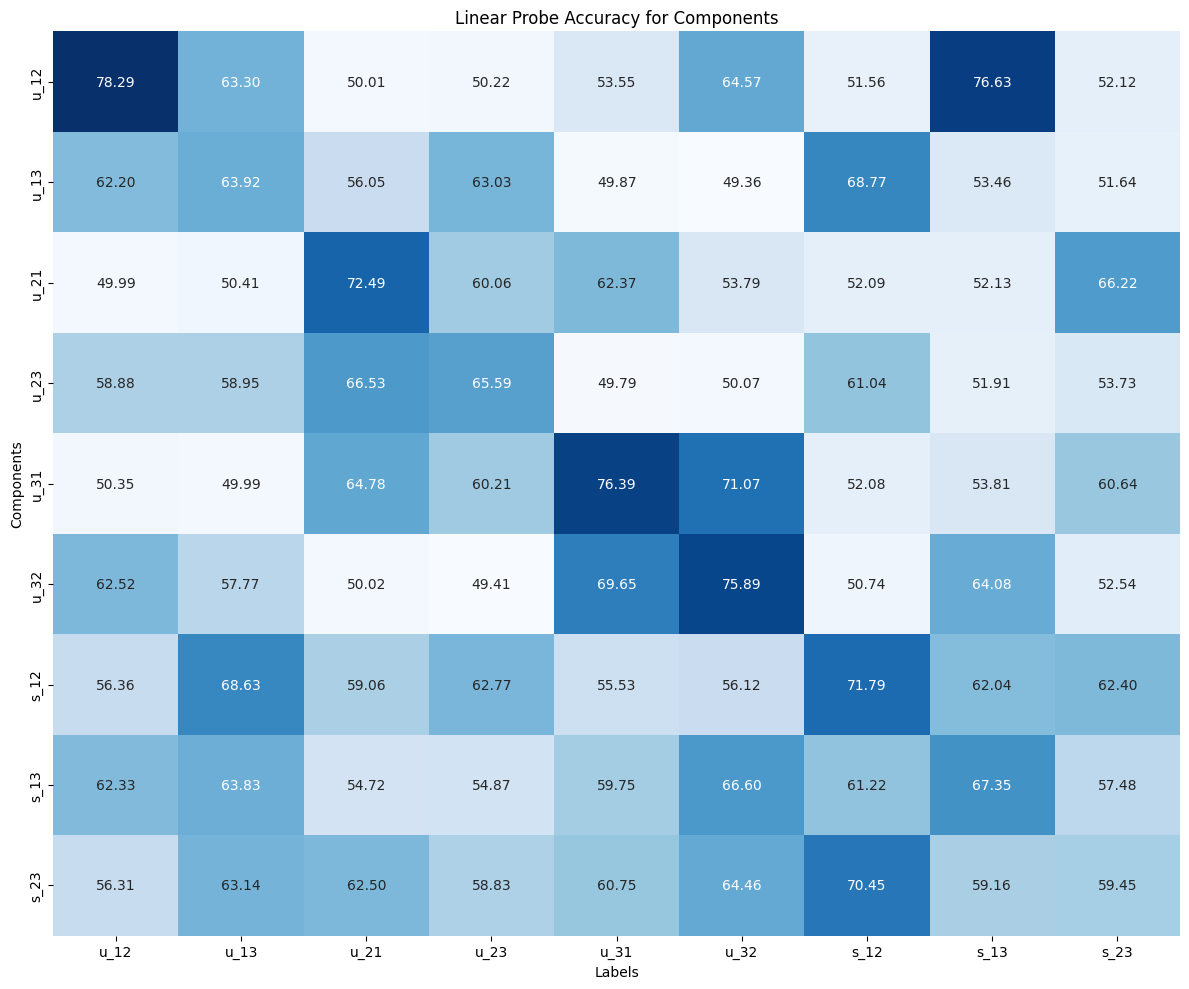

In [34]:
import matplotlib.pyplot as plt
plot_confusion_matrix(linear_results["acc"], labels= list(linear_results["acc"].keys()), components= list(linear_results["acc"].keys()))
plt.close("all")

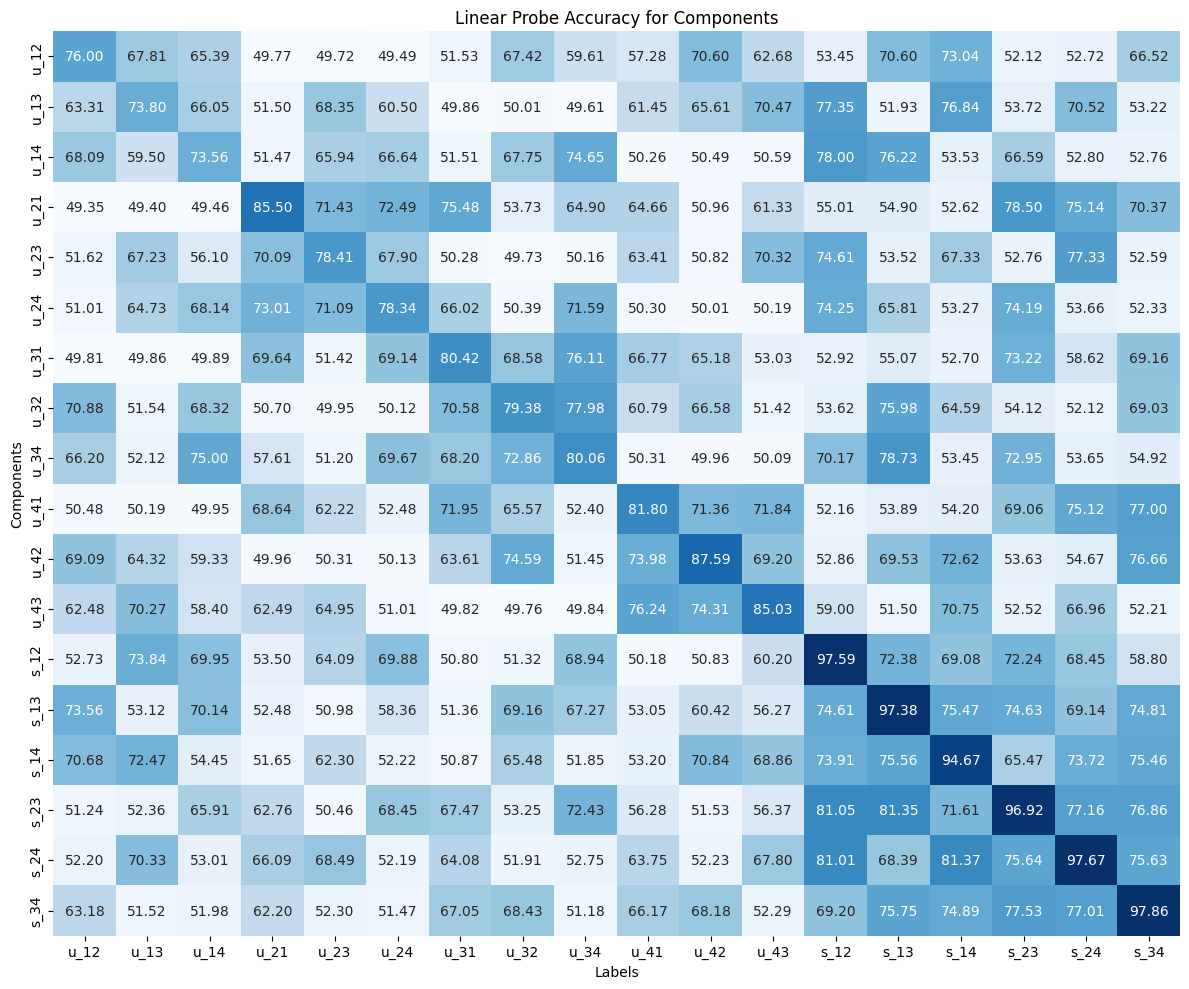

In [ ]:
import matplotlib.pyplot as plt

plot_confusion_matrix(linear_probe_acc, labels= components, components= components)
plt.close("all")

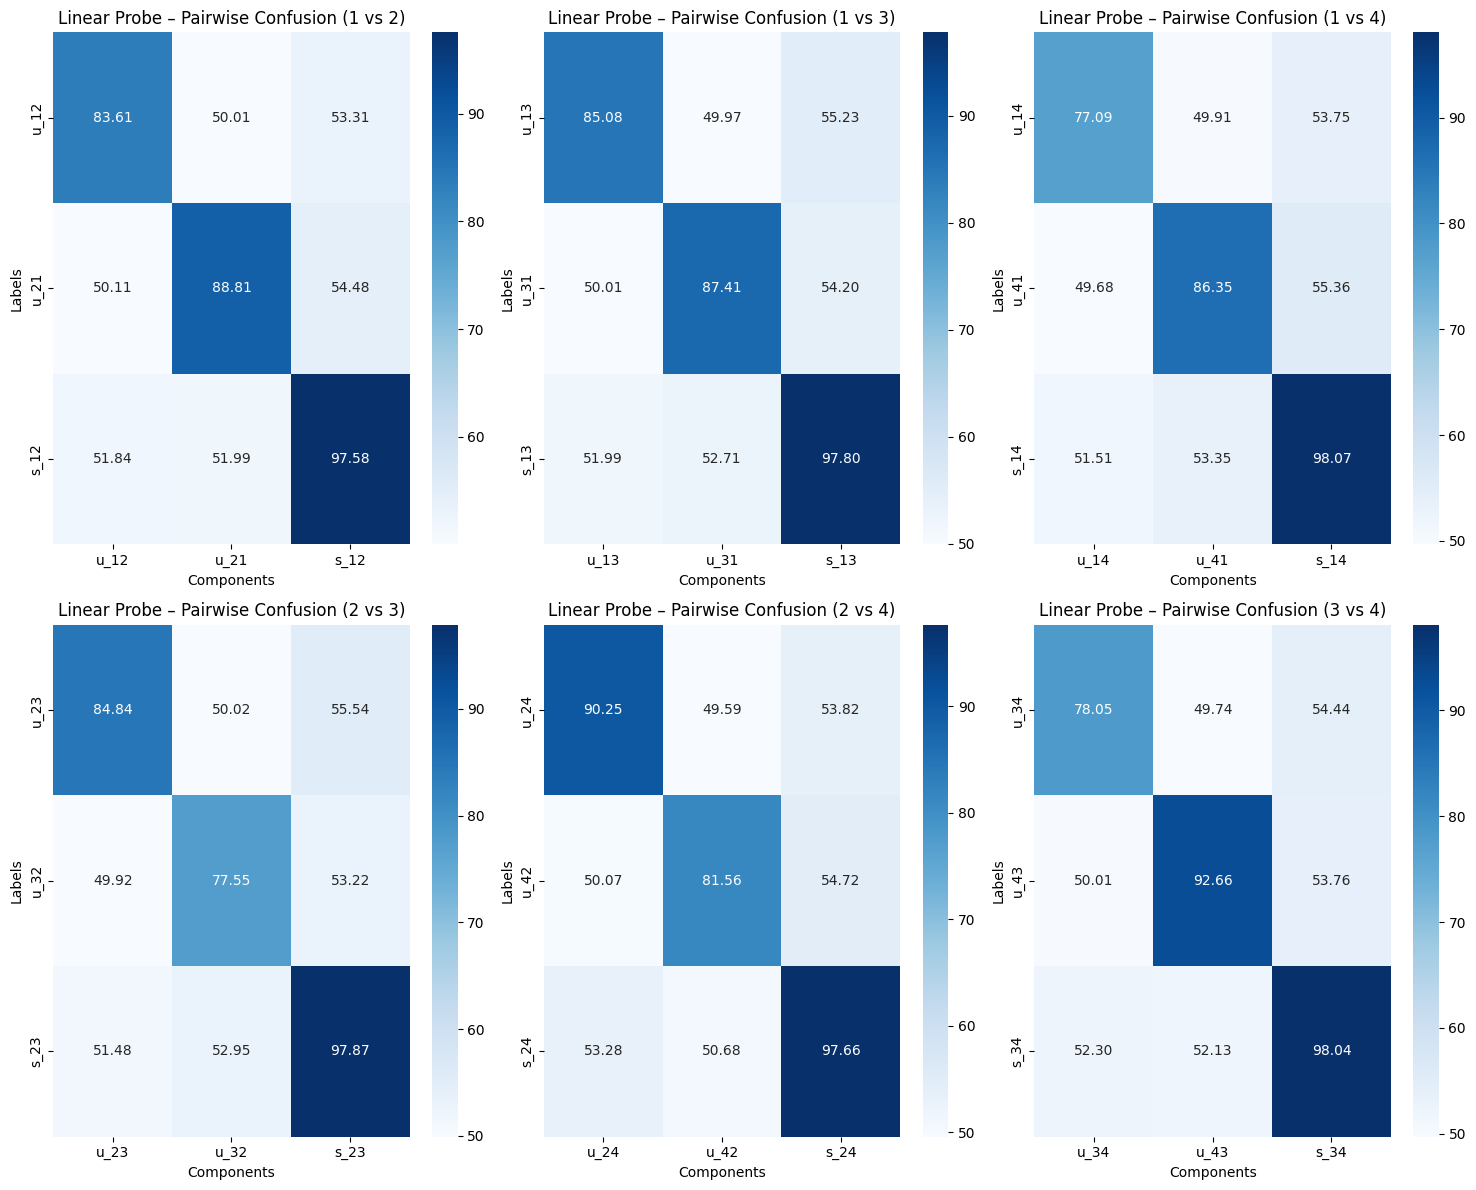

In [ ]:
from src.utils.helpers import plot_pairwise_confusion_matrices
from itertools import combinations
M = 4

plot_pairwise_confusion_matrices(linear_probe_acc, M= 4, components= components, pairs = list(combinations(range(M), 2)))
plt.close("all")

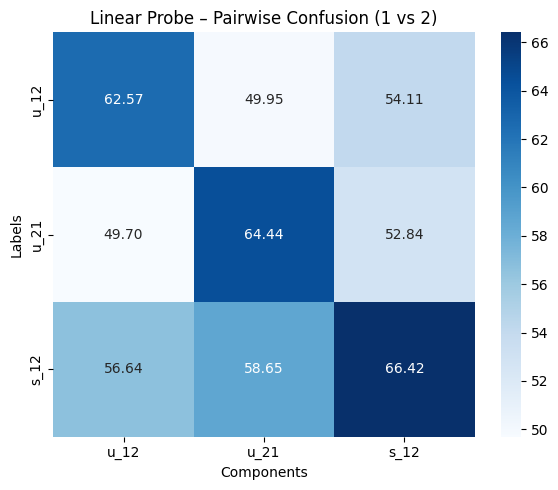

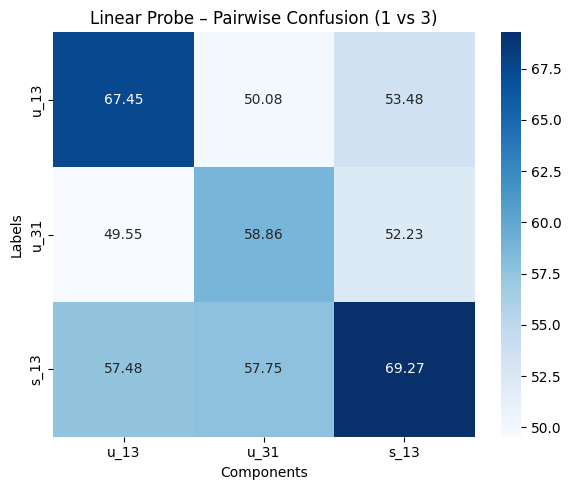

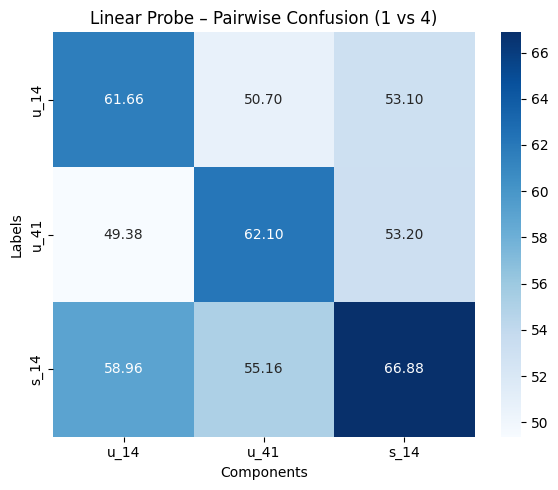

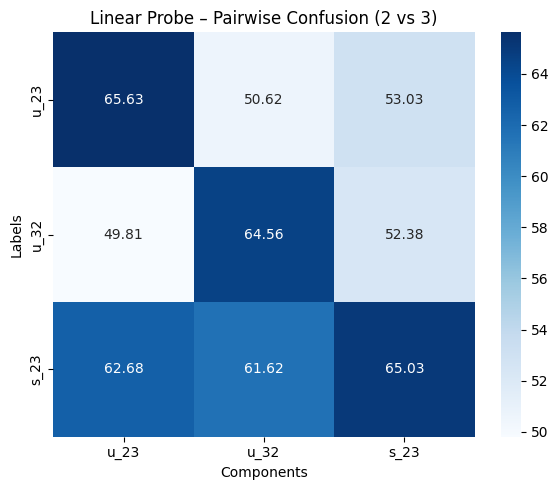

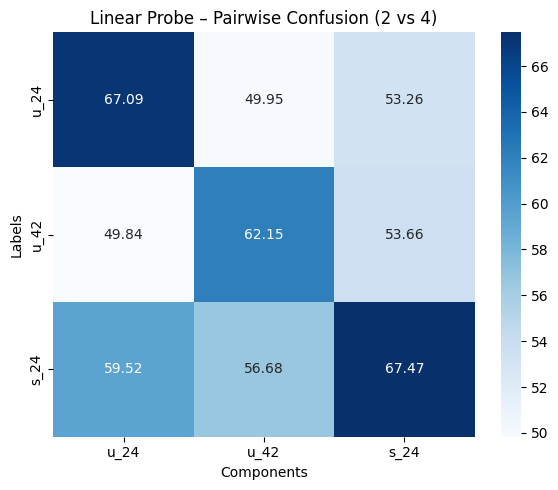

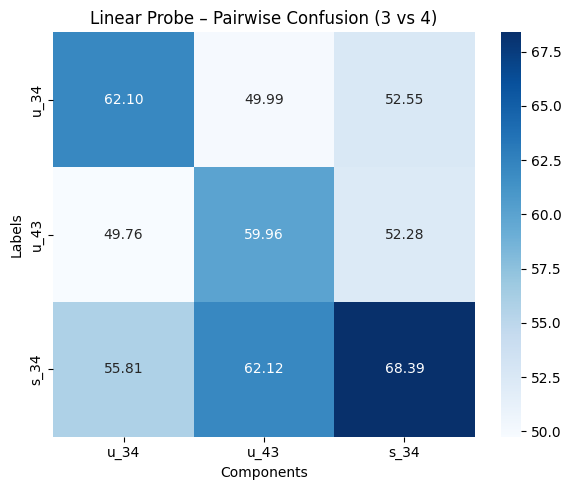

In [ ]:
def parse_pair(key):
    # "u_12" or "s_23"
    i = int(key[2]) - 1
    j = int(key[3]) - 1
    return i, j

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

def plot_pairwise_confusion_matrices(linear_probe_acc, M, figsize=(5, 4)):
    """
    Plot M*(M-1)/2 confusion matrices, one per modality pair.

    Rows: labels
    Columns: components
    Values: linear probe accuracy
    """

    # reconstruct component & label keys (same set)
    label_keys = list(linear_probe_acc.keys())
    comp_keys = label_keys.copy()

    # build full accuracy matrix (rows=labels, cols=components)
    A = np.stack([linear_probe_acc[k] for k in label_keys], axis=0)

    # all unordered modality pairs
    pairs = list(combinations(range(M), 2))

    for (i, j) in pairs:
        pair_name = f"{i+1} vs {j+1}"

        # columns: u_ij, u_ji, s_ij
        col_keys = [f"u_{i+1}{j+1}", f"u_{j+1}{i+1}", f"s_{i+1}{j+1}"]
        col_idx = [comp_keys.index(k) for k in col_keys]

        # rows: same pairwise labels
        row_keys = col_keys
        row_idx = [label_keys.index(k) for k in row_keys]

        submat = A[np.ix_(row_idx, col_idx)]

        plt.figure(figsize=figsize)
        sns.heatmap(
            submat,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=col_keys,
            yticklabels=row_keys,
            cbar=True,
        )
        plt.title(f"Linear Probe – Pairwise Confusion ({pair_name})")
        plt.xlabel("Components")
        plt.ylabel("Labels")
        plt.tight_layout()
        plt.show()
plot_pairwise_confusion_matrices(linear_probe_acc, M= data_config["create_data"]["M"], figsize=(6, 5))

In [ ]:
model.eval()
    
with torch.no_grad():
    for batch_idx, (X, labels_u, labels_s) in enumerate(train_dataloader):
        temp_b = X[0].shape[0]
        X = [X[m].to(device) for m in range(len(X))]

        # Augment data
        X_aug = [GenerateData.augment_data(X[m], aug_type="random") for m in range(len(X))]
        
        out = model(X)
        out_aug = model(X_aug)
        print(out['U'].shape)
        break

torch.Size([1024, 3, 3, 16])


### Calculate linear probing accuracy

In [ ]:
# Linear probing evaluation
print("Extracting latents from train and test datasets...")

# Extract latents and labels from train and test sets
train_data_dict = extract_latents_and_labels(model, train_dataloader, device)
test_data_dict = extract_latents_and_labels(model, test_dataloader, device)

Extracting latents from train and test datasets...


In [ ]:
linear_probe_acc = {"u_12": np.zeros(3), "u_21": np.zeros(3), "s": np.zeros(3)}
for i, label in enumerate(['labels_1', 'labels_2', 'labels_s']):
    print(f"\nEvaluating disentanglement for {label}...")
    
    # Unique component of modality 1
    linear_probe_acc["u_12"][i] = linear_probe(
        train_data_dict['u_12'], train_data_dict[label],
        test_data_dict['u_12'], test_data_dict[label]
    )
    print(f"  Unique component of modality 1 accuracy: {linear_probe_acc['u_12'][i]:.2f}%")
    # Unique component of modality 2
    linear_probe_acc["u_21"][i] = linear_probe(
        train_data_dict['u_21'], train_data_dict[label],
        test_data_dict['u_21'], test_data_dict[label]
    )
    print(f"  Unique component of modality 2 accuracy: {linear_probe_acc['u_21'][i]:.2f}%")
    # Shared component from modality 2
    linear_probe_acc["s"][i] = linear_probe(
        np.concatenate((train_data_dict['s_21'], train_data_dict['s_12']), axis= -1), train_data_dict[label],
        np.concatenate((test_data_dict['s_21'], test_data_dict['s_12']), axis= -1), test_data_dict[label]
    )
    print(f"  Shared component accuracy: {linear_probe_acc['s'][i]:.2f}%")
    
input_linear_probe_acc = {"x_12": np.zeros(3), "x_21": np.zeros(3), "xs": np.zeros(3)}
for i, label in enumerate(['labels_1', 'labels_2', 'labels_s']):
    print(f"\nEvaluating input data for {label}...")
    
    # Input data from modality 1
    input_linear_probe_acc["x_12"][i] = linear_probe(
        train_data_dict['x_12'], train_data_dict[label],
        test_data_dict['x_12'], test_data_dict[label]
    )
    print(f"  Input data from modality 1 accuracy: {input_linear_probe_acc['x_12'][i]:.2f}%")
    # Input data from modality 2
    input_linear_probe_acc["x_21"][i] = linear_probe(
        train_data_dict['x_21'], train_data_dict[label],
        test_data_dict['x_21'], test_data_dict[label]
    )
    print(f"  Input data from modality 2 accuracy: {input_linear_probe_acc['x_21'][i]:.2f}%")
    # Shared input data
    input_linear_probe_acc["xs"][i] = linear_probe(
        np.concatenate((train_data_dict['xs_21'], train_data_dict['xs_12']), axis= -1), train_data_dict[label],
        np.concatenate((test_data_dict['xs_21'], test_data_dict['xs_12']), axis= -1), test_data_dict[label]
    )
    print(f"  Shared input data accuracy: {input_linear_probe_acc['xs'][i]:.2f}%")


Evaluating disentanglement for labels_1...
  Unique component of modality 1 accuracy: 71.36%
  Unique component of modality 2 accuracy: 49.30%
  Shared component accuracy: 54.07%

Evaluating disentanglement for labels_2...
  Unique component of modality 1 accuracy: 49.16%
  Unique component of modality 2 accuracy: 80.27%
  Shared component accuracy: 53.35%

Evaluating disentanglement for labels_s...
  Unique component of modality 1 accuracy: 51.19%
  Unique component of modality 2 accuracy: 52.13%
  Shared component accuracy: 91.76%

Evaluating input data for labels_1...
  Input data from modality 1 accuracy: 97.14%
  Input data from modality 2 accuracy: 49.56%
  Shared input data accuracy: 50.01%

Evaluating input data for labels_2...
  Input data from modality 1 accuracy: 50.03%
  Input data from modality 2 accuracy: 95.47%
  Shared input data accuracy: 50.08%

Evaluating input data for labels_s...
  Input data from modality 1 accuracy: 50.16%
  Input data from modality 2 accuracy: 

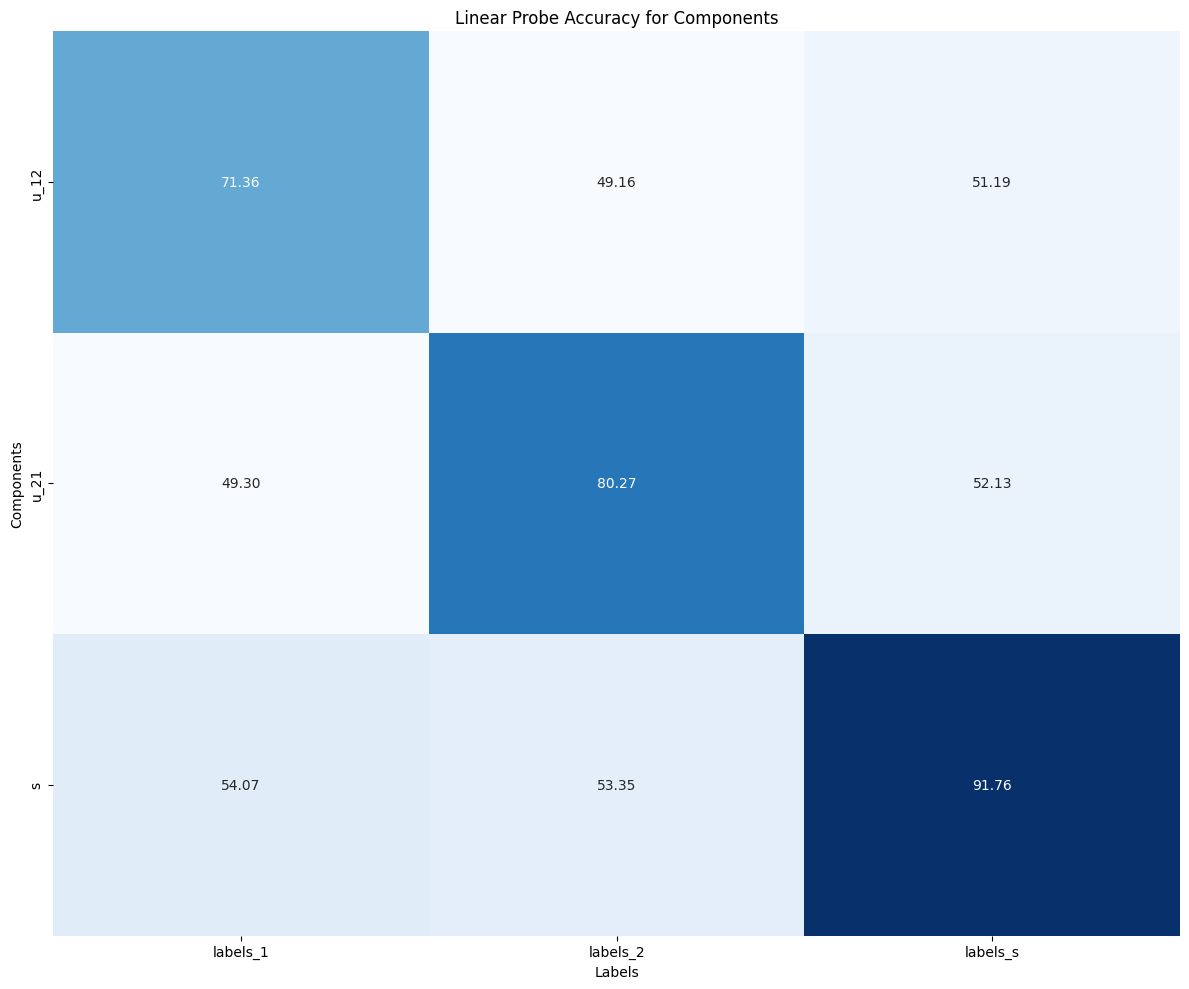

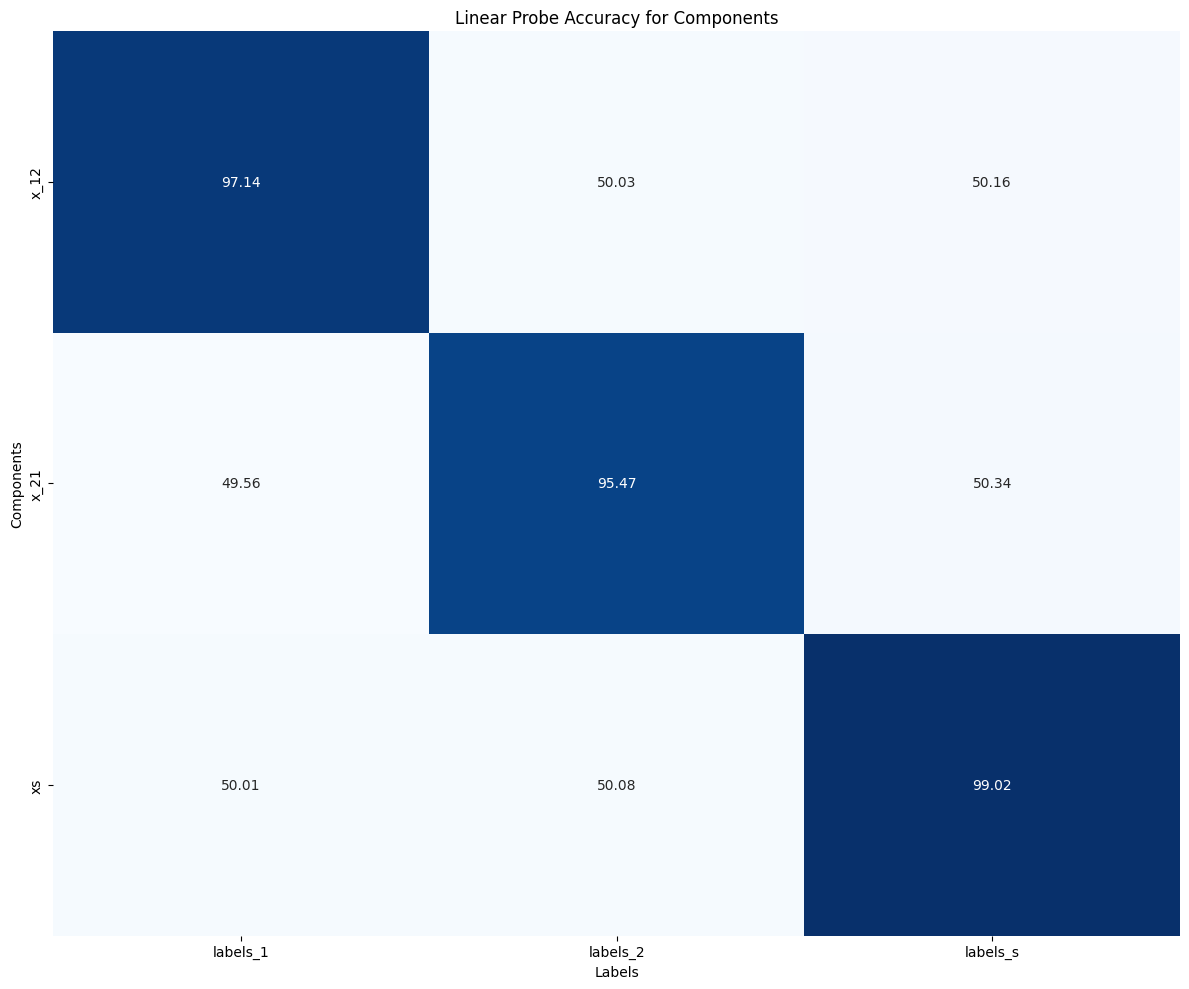

In [ ]:
plot_confusion_matrix(linear_probe_acc)
plot_confusion_matrix(input_linear_probe_acc, components= ['x_12', 'x_21', 'xs'])

### Same but non-linear probing

In [ ]:
non_linear_probe_acc = {"u_12": np.zeros(3), "u_21": np.zeros(3), "s": np.zeros(3)}
for i, label in enumerate(['labels_1', 'labels_2', 'labels_s']):
    print(f"\nEvaluating disentanglement for {label}...")
    
    # Unique component of modality 1
    non_linear_probe_acc["u_12"][i] = non_linear_probe(
        train_data_dict['u_12'], train_data_dict[label],
        test_data_dict['u_12'], test_data_dict[label]
    )
    print(f"  Unique component of modality 1 accuracy: {non_linear_probe_acc['u_12'][i]:.2f}%")
    # Unique component of modality 2
    non_linear_probe_acc["u_21"][i] = non_linear_probe(
        train_data_dict['u_21'], train_data_dict[label],
        test_data_dict['u_21'], test_data_dict[label]
    )
    print(f"  Unique component of modality 2 accuracy: {non_linear_probe_acc['u_21'][i]:.2f}%")
    # Shared component from modality 2
    non_linear_probe_acc["s"][i] = non_linear_probe(
        np.concatenate((train_data_dict['s_21'], train_data_dict['s_12']), axis= -1), train_data_dict[label],
        np.concatenate((test_data_dict['s_21'], test_data_dict['s_12']), axis= -1), test_data_dict[label]
    )
    print(f"  Shared component accuracy: {non_linear_probe_acc['s'][i]:.2f}%")

input_non_linear_probe_acc = {"x_12": np.zeros(3), "x_21": np.zeros(3), "xs": np.zeros(3)}
for i, label in enumerate(['labels_1', 'labels_2', 'labels_s']):
    print(f"\nEvaluating input data for {label}...")
    
    # Input data from modality 1
    input_non_linear_probe_acc["x_12"][i] = non_linear_probe(
        train_data_dict['x_12'], train_data_dict[label],
        test_data_dict['x_12'], test_data_dict[label]
    )
    print(f"  Input data from modality 1 accuracy: {input_non_linear_probe_acc['x_12'][i]:.2f}%")
    # Input data from modality 2
    input_non_linear_probe_acc["x_21"][i] = non_linear_probe(
        train_data_dict['x_21'], train_data_dict[label],
        test_data_dict['x_21'], test_data_dict[label]
    )
    print(f"  Input data from modality 2 accuracy: {input_non_linear_probe_acc['x_21'][i]:.2f}%")
    # Shared input data
    input_non_linear_probe_acc["xs"][i] = non_linear_probe(
        np.concatenate((train_data_dict['xs_21'], train_data_dict['xs_12']), axis= -1), train_data_dict[label],
        np.concatenate((test_data_dict['xs_21'], test_data_dict['xs_12']), axis= -1), test_data_dict[label]
    )
    print(f"  Shared input data accuracy: {input_non_linear_probe_acc['xs'][i]:.2f}%")
    


Evaluating disentanglement for labels_1...
  Unique component of modality 1 accuracy: 73.17%
  Unique component of modality 2 accuracy: 50.18%
  Shared component accuracy: 50.23%

Evaluating disentanglement for labels_2...
  Unique component of modality 1 accuracy: 49.71%
  Unique component of modality 2 accuracy: 64.22%
  Shared component accuracy: 52.08%

Evaluating disentanglement for labels_s...
  Unique component of modality 1 accuracy: 50.72%
  Unique component of modality 2 accuracy: 51.66%
  Shared component accuracy: 82.30%

Evaluating input data for labels_1...
  Input data from modality 1 accuracy: 99.30%
  Input data from modality 2 accuracy: 50.19%
  Shared input data accuracy: 50.06%

Evaluating input data for labels_2...
  Input data from modality 1 accuracy: 49.90%
  Input data from modality 2 accuracy: 99.31%
  Shared input data accuracy: 49.84%

Evaluating input data for labels_s...
  Input data from modality 1 accuracy: 49.29%
  Input data from modality 2 accuracy: 

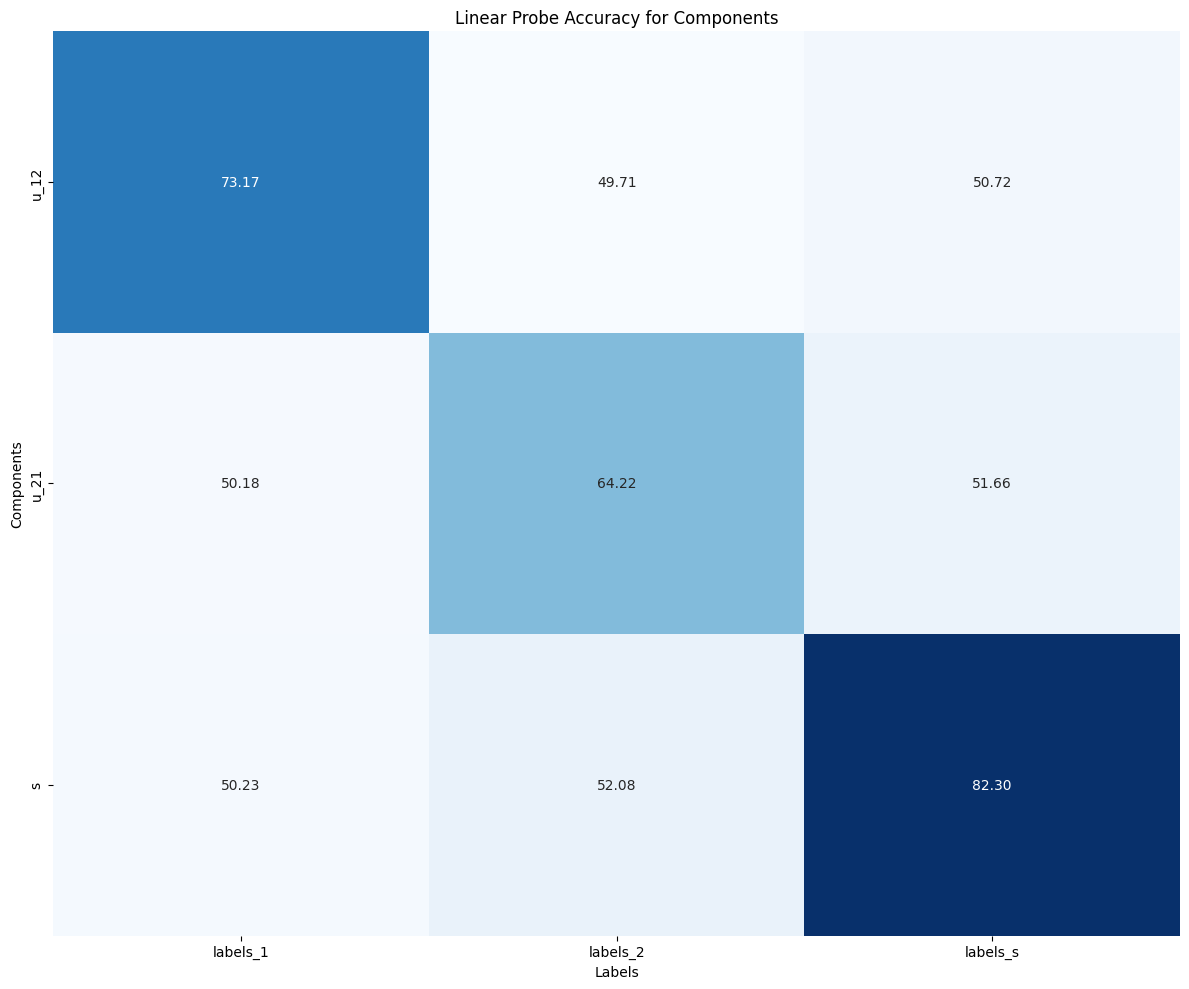

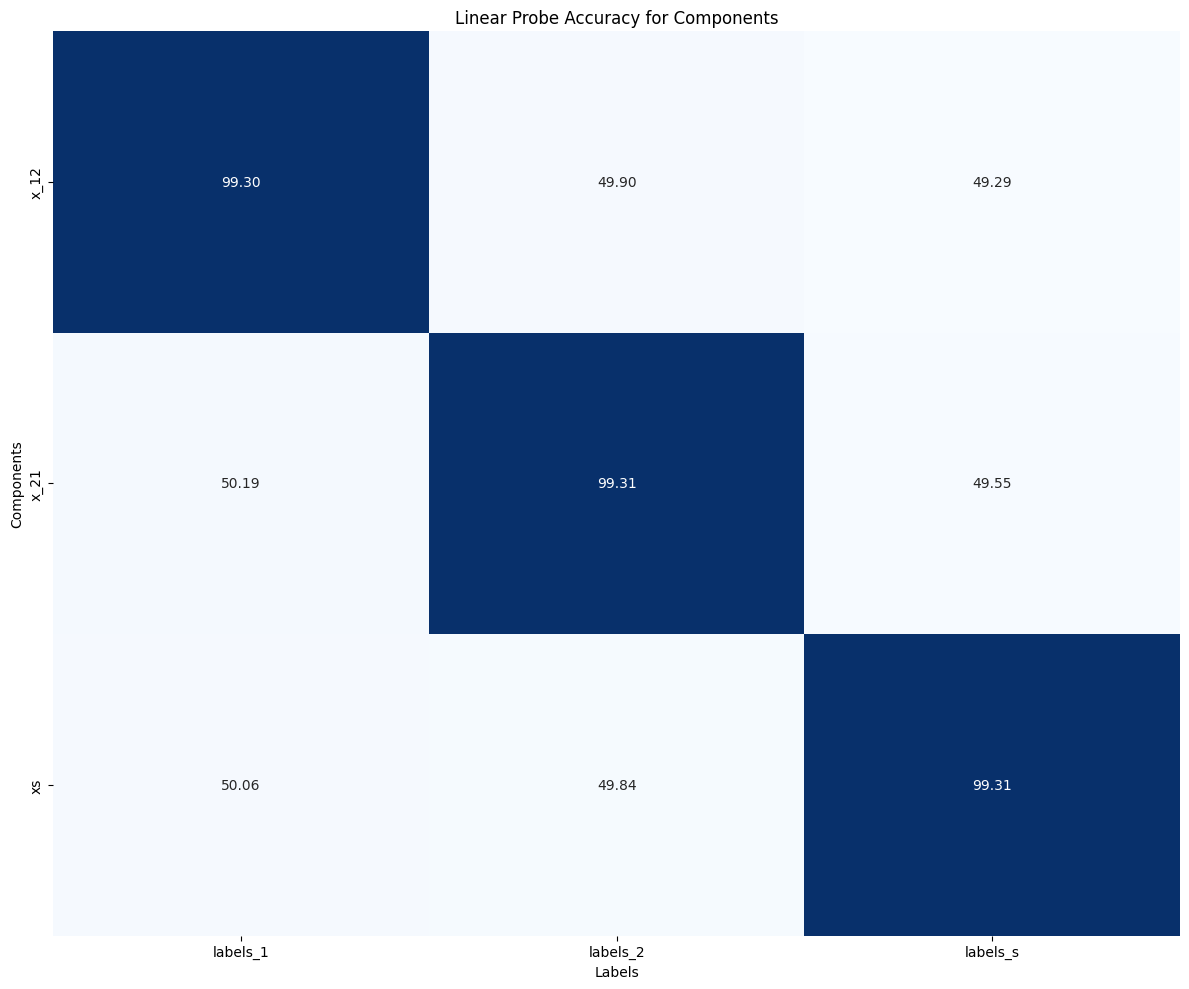

In [ ]:
plot_confusion_matrix(non_linear_probe_acc)
plot_confusion_matrix(input_non_linear_probe_acc, components= ['x_12', 'x_21', 'xs'])

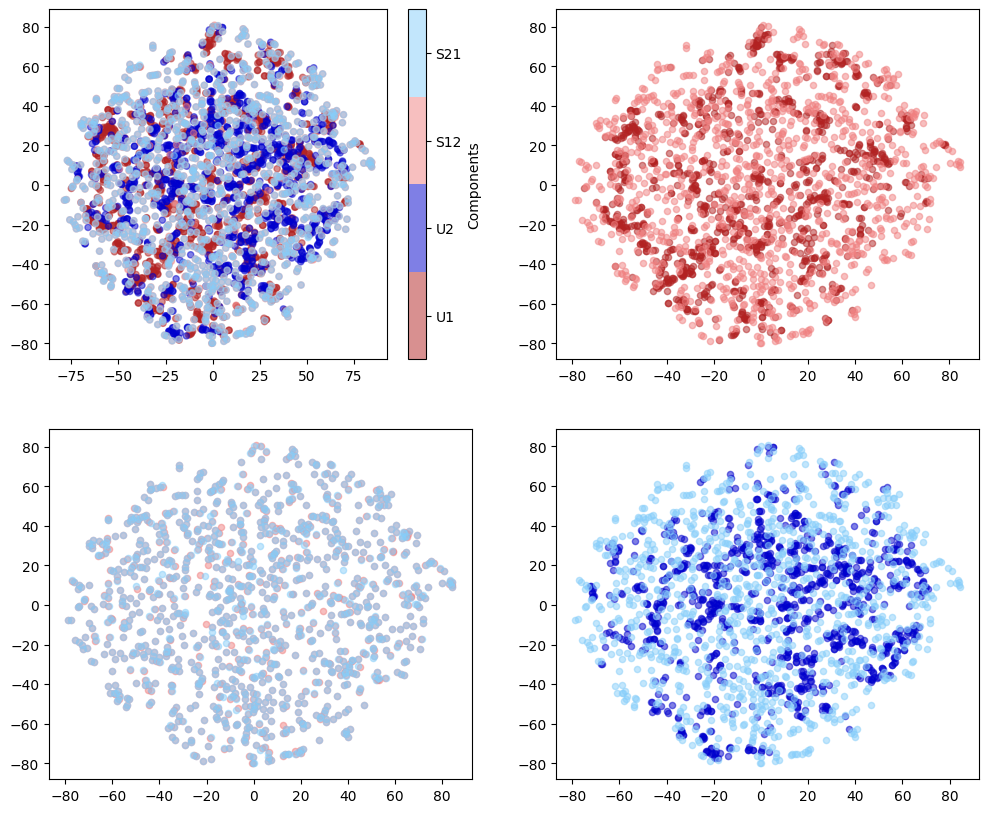

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
import pickle as pkl

# Extract the disentangled components from the trained model
model.eval()


# Use a batch from the dataset for visualization
data_m1_viz, data_m2_viz, _, _, _ = next(iter(test_dataloader))

data_m1_viz = data_m1_viz.to(device)
data_m2_viz = data_m2_viz.to(device)

# Forward pass to extract disentangled components
with torch.no_grad():
    outputs_viz = model(data_m1_viz, data_m2_viz)
    
    # Extract components
    z_1 = outputs_viz['Z1'][0].cpu().numpy()  # Unique component from modality 1
    z_2 = outputs_viz['Z2'][0].cpu().numpy()  # Unique component from modality 2
    s_12 = outputs_viz['Z1'][1].cpu().numpy() # shared component from modality 1
    s_21 = outputs_viz['Z2'][1].cpu().numpy() # shared component from modality 2
    
    size = z_1.shape[0]

    labels = [0] * size + [1] * size + size * [2] + size * [3]
    
    # t-SNE 2D visualization
    # Concatenate all components for t-SNE
    concat = np.concatenate([z_1, z_2, s_12, s_21], axis=0)

    # t-SNE 2D visualization
    best_kl = float('inf')
    
    best_tsne = None
    for i in range(10):
        tsne = TSNE(n_components=2, random_state= i, perplexity=20)
        tsne.fit(concat)
        temp_kl = tsne.kl_divergence_
        if temp_kl < best_kl:
            best_kl = temp_kl
            best_tsne = tsne
    tsne_result = best_tsne.fit_transform(concat)



    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    colors = ['#b22222', '#0000cd', '#f08080', '#87cefa']  # dark red, light red, dark blue, light blue

    # Create colormap
    cmap = ListedColormap(colors)
    scatter3 = ax[0, 0].scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap= cmap, alpha=0.5, s= 20)

    # Discrete colorbar for four labels
    cbar = fig.colorbar(scatter3, ax=ax[0, 0], ticks=[0, 1, 2, 3], boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5])
    cbar.set_label('Components')
    cbar.set_ticklabels(['U1', 'U2', 'S12', 'S21'])

    ax[0, 1].scatter(tsne_result[:size, 0], tsne_result[:size, 1], c= colors[0], label='U1', alpha=0.5, s=20)
    ax[0, 1].scatter(tsne_result[2*size:3*size, 0], tsne_result[2*size:3*size, 1], c=colors[2], label='S12', alpha=0.5, s=20)

    ax[1, 1].scatter(tsne_result[size:2*size, 0], tsne_result[size:2*size, 1], c= colors[1], label='U2', alpha=0.5, s=20)
    ax[1, 1].scatter(tsne_result[3*size:, 0], tsne_result[3*size:, 1], c=colors[3], label='S21', alpha=0.5, s=20)
    
    ax[1, 0].scatter(tsne_result[2*size:3*size, 0], tsne_result[2*size:3*size, 1], c=colors[2], label='S12', alpha=0.5, s=20)
    ax[1, 0].scatter(tsne_result[3*size:, 0], tsne_result[3*size:, 1], c=colors[3], label='S21', alpha=0.5, s=20)
    plt.show()